Cruz Grimaldez Manuel Dominique

GL1

# Ejercicion de programación - Regresión Logistica

En este ejercicio se implementa regresion logistica y se aplica a dos diferentes datasets.

In [1]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np
import pandas as pd

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

## 1 Regresion Logistica

En esta parte del ejercicio, creará un modelo de regresión logística para predecir si un estudiante será admitido en una universidad. Suponga que es el administrador de un departamento universitario y desea determinar las posibilidades de admisión de cada solicitante en función de sus resultados en dos exámenes. Tiene datos históricos de solicitantes anteriores que puede usar como un conjunto de capacitación para la regresión logística. Para cada ejemplo de capacitación, se tiene las calificaciones del solicitante en dos exámenes y la decisión de admisión. Su tarea es crear un modelo de clasificación que calcule la probabilidad de admisión de un solicitante en función de los puntajes de esos dos exámenes.

La siguiente celda cargará los datos y las etiquetas correspondientes:

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Cargar datos
# Las dos primeras columnas contienen la nota de dos examenes y la tercera columna
# contiene la etiqueta que indica si el alumno ingreso o no a la universidad.
# data = np.loadtxt(os.path.join('data', 'ex2data1.txt'), delimiter=',')


# Cargar dataset (ajusta la ruta al tuyo)
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/preapuntes IA/Mi repositorio/Laboratorios/Lab3/KaggleV2-May-2016.csv')

# Revisar columnas
print(df.head())

# Seleccionar caracteristicas (X) y variable objetivo (y)
# Convertir 'No-show' a valores numéricos (0 para 'No', 1 para 'Yes')
df['No-show'] = df['No-show'].apply(lambda x: 1 if x == 'Yes' else 0)

# Seleccionar las columnas para X (caracteristicas) y y (variable objetivo)
selected_features = ['Age', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received']
X = df[selected_features].values
y = df['No-show'].values

# Imprimir las primeras filas de X e y para verificar
print("\nPrimeras filas de X:")
print(X[:5])
print("\nPrimeras filas de y:")
print(y[:5])

      PatientId  AppointmentID Gender          ScheduledDay  \
0  2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1  5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2  4.262962e+12        5642549      F  2016-04-29T16:19:04Z   
3  8.679512e+11        5642828      F  2016-04-29T17:29:31Z   
4  8.841186e+12        5642494      F  2016-04-29T16:07:23Z   

         AppointmentDay  Age      Neighbourhood  Scholarship  Hipertension  \
0  2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0             1   
1  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             0   
2  2016-04-29T00:00:00Z   62      MATA DA PRAIA            0             0   
3  2016-04-29T00:00:00Z    8  PONTAL DE CAMBURI            0             0   
4  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             1   

   Diabetes  Alcoholism  Handcap  SMS_received No-show  
0         0           0        0             0      No  
1         0           0        0      

### 1.1 Visualizar los datos

Antes de comenzar a implementar cualquier algoritmo de aprendizaje, siempre es bueno visualizar los datos si es posible. Mostramos los datos en una gráfica bidimensional llamando a la función `plotData`. Se completará el código en `plotData` para que muestre una figura donde los ejes son los dos puntajes de los dos examenes, los ejemplos positivos y negativos se muestran con diferentes marcadores.

In [6]:
def plotData(X, y):
    # Gragica los puntos de datos X y y en una nueva figura. Grafica los puntos de datos con * para los positivos y
    # o para los negativos.

    # Crea una nueva figura
    fig = pyplot.figure()

    # Find Indices of Positive and Negative Examples
    pos = y == 1
    neg = y == 0

    # Plot Examples
    # Se grafican las dos primeras columnas de X (despues de agregar la columna de unos)
    pyplot.plot(X[pos, 1], X[pos, 2], 'k*', lw=2, ms=10)
    pyplot.plot(X[neg, 1], X[neg, 2], 'ko', mfc='y', ms=8, mec='k', mew=1)


Se llama a la función implementada para mostrar los datos cargados:

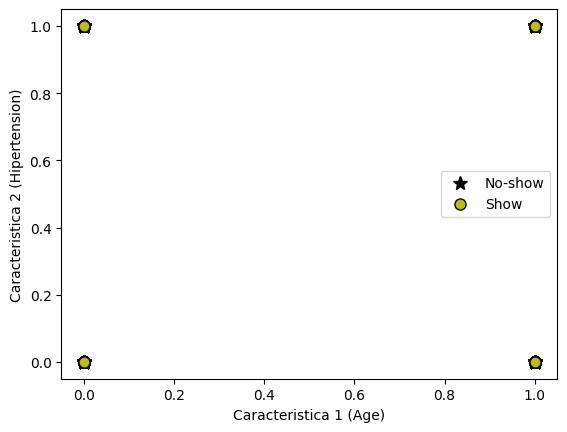

In [7]:
plotData(X, y)
# adiciona etiquetas para los ejes
pyplot.xlabel('Caracteristica 1 (Age)') # Etiqueta genérica, ajusta si graficas otras caracteristicas
pyplot.ylabel('Caracteristica 2 (Hipertension)') # Etiqueta genérica, ajusta si graficas otras caracteristicas
pyplot.legend(['No-show', 'Show']) # Ajusta las etiquetas de la leyenda segun tu variable objetivo
pass

<a id="section1"></a>
### 1.2 Implementacion

#### 1.2.1 Fución Sigmoidea

La hipotesis para la regresión logistica se define como:

$$ h_\theta(x) = g(\theta^T x)$$

donde la función $g$ es la función sigmoidea. La función sigmoidea se define como:

$$g(z) = \frac{1}{1+e^{-z}}$$.

Los resultados que debe generar la funcion sigmoidea para valores positivos amplios de `x`, deben ser cercanos a 1, mientras que para valores negativos grandes, la sigmoide debe generar valores cercanos 0. La evaluacion de `sigmoid(0)` debe dar un resultado exacto de 0.5. Esta funcion tambien debe poder trabajar con vectores y matrices.

In [8]:
def calcularSigmoide(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

Se calcula el valor de la sigmoide aplicando la funcion sigmoid con `z=0`, se debe obtener un resultado de 0.5. RE recomienda experimentar con otros valores de `z`.

In [9]:
# Prueba la implementacion de la funcion sigmoid
z = [-9099991, 309000000, 0]
g = calcularSigmoide(z)

print('g(', z, ') = ', g)

g( [-9099991, 309000000, 0] ) =  [0.  1.  0.5]


/tmp/ipython-input-3890281146.py:8: RuntimeWarning: overflow encountered in exp
  g = 1 / (1 + np.exp(-z))


<a id="section2"></a>
#### 1.2.2 Función de Costo y Gradiente

Se implementa la funcion cost y gradient, para la regresión logistica. Antes de continuar es importante agregar el termino de intercepcion a X.

In [11]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = X.shape
# Agraga el termino de intercepción a A
X = np.concatenate([np.ones((m, 1)), X], axis=1)

print(X[:])

[[ 1.  1. 62. ...  0.  0.  0.]
 [ 1.  1. 56. ...  0.  0.  0.]
 [ 1.  1. 62. ...  0.  0.  0.]
 ...
 [ 1.  1. 21. ...  0.  0.  1.]
 [ 1.  1. 38. ...  0.  0.  1.]
 [ 1.  1. 54. ...  0.  0.  1.]]


La funcion de costo en una regresión logistica es:

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$

y el gradiente del costo es un vector de la misma longitud como $\theta$ donde el elemento $j^{th}$ (para $j = 0, 1, \cdots , n$) se define como:

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)} $$

Si bien este gradiente parece idéntico al gradiente de regresión lineal, la fórmula es diferente porque la regresión lineal y logística tienen diferentes definiciones de $h_\theta(x)$.
<a id="costFunction"></a>

In [12]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = calcularSigmoide(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [13]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = calcularSigmoide(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

theta calculado por el descenso por el gradiente: [-0.37696186 -0.37696186 -0.01533105  0.02920493  0.01708008  0.00394141
 -0.00218198  0.10607192]


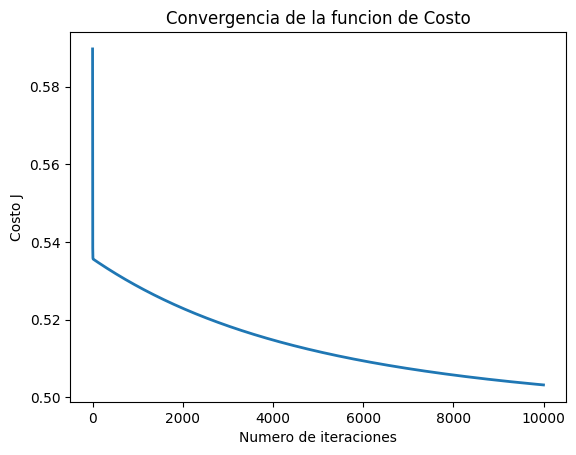

In [16]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001
num_iters = 10000 # Reducido el numero de iteraciones

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1]) # Modificado para inicializar theta con la dimension correcta
theta, J_history = descensoGradiente(theta, X, y, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia de la funcion de Costo') # Añadido titulo al grafico

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

In [17]:
print(J_history[-1])

0.5032193520502


In [20]:
# verificar si ingresa o no a la universidad
# X_array = [1, 30, 50] # Ejemplo original con 2 caracteristicas + intercepcion
# Ahora con las caracteristicas seleccionadas: [1, Age, Hipertension, Diabetes, Alcoholism, Handcap, SMS_received]
X_array = [1, 30, 0, 0, 0, 0, 0, 0] # Ejemplo: persona de 30 años, sin hipertension, diabetes, alcoholismo, handcap, sin SMS recibido (8 elementos)
aprueba = calcularSigmoide(np.dot(X_array, theta))

print(f"Probabilidad de no-show para una persona con Age: {X_array[1]}, Hipertension: {X_array[2]}, Diabetes: {X_array[3]}, Alcoholism: {X_array[4]}, Handcap: {X_array[5]}, SMS_received: {X_array[6]} (usando el descenso por el gradiente): {aprueba}")

Probabilidad de no-show para una persona con Age: 30, Hipertension: 0, Diabetes: 0, Alcoholism: 0, Handcap: 0, SMS_received: 0 (usando el descenso por el gradiente): 8.412211539514948e-06


In [22]:
# verificar si ingresa o no a la universidad
# X_array = [1, 80, 90] # Ejemplo original con 2 caracteristicas
# Ahora con las caracteristicas seleccionadas: [1, Age, Hipertension, Diabetes, Alcoholism, Handcap, SMS_received]
X_array = [1, 60, 1, 0, 0, 1, 1, 1] # Nuevo Ejemplo: persona de 60 años, con hipertension, sin diabetes, sin alcoholismo, con handcap, con SMS recibido
aprueba = calcularSigmoide(np.dot(X_array, theta))

print(f"Probabilidad de no-show para una persona con Age: {X_array[1]}, Hipertension: {X_array[2]}, Diabetes: {X_array[3]}, Alcoholism: {X_array[4]}, Handcap: {X_array[5]}, SMS_received: {X_array[6]} (usando el descenso por el gradiente):{aprueba}")

Probabilidad de no-show para una persona con Age: 60, Hipertension: 1, Diabetes: 0, Alcoholism: 0, Handcap: 1, SMS_received: 1 (usando el descenso por el gradiente):1.1316509745503044e-10
